# COS30082 - Supervised Learning (Classification-Based)

> Aston Lynch - 103964552

## 1. Imports and setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tensorflow as tf
import keras as tfk
from keras import layers as tkl

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1779587708.734794    6129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779587708.914015    6129 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779587710.069911    6129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
IMG_SIZE = (128, 128)
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 64
EMBEDDING_DIM = 128
LEARNING_RATE = 1e-4
EPOCHS = 100
DATA_DIR = '../data/dataset/classification_data'

## 2. Data Loading

In [3]:
train_dataset = tfk.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train_data'),
    validation_split=0.2,
    subset='training',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_dataset = tfk.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train_data'),
    validation_split=0.2,
    subset='validation',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Training identities: {num_classes}")
print(f"Training batches: {train_dataset.cardinality().numpy()}")
print(f"Validation batches: {val_dataset.cardinality().numpy()}")

Found 380638 files belonging to 4000 classes.
Using 304511 files for training.


I0000 00:00:1779587723.148862    6129 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12925 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 380638 files belonging to 4000 classes.
Using 76127 files for validation.
Training identities: 4000
Training batches: 4758
Validation batches: 1190


## 3. Augmentation and Preprocessing

In [4]:
data_augmentation = tfk.Sequential([
    tkl.RandomFlip('horizontal'),
    tkl.RandomRotation(0.1),
    tkl.RandomZoom(0.1),
], name='data_augmentation')

preprocess_input = tfk.applications.mobilenet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(buffer_size=AUTOTUNE)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(buffer_size=AUTOTUNE)

## 4. Model Building

In [5]:
base_model = tfk.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
)

base_model.trainable = False
for layer in base_model.layers[-11:]:
    layer.trainable = True

inputs = tfk.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tkl.GlobalAveragePooling2D()(x)
x = tkl.Dropout(0.3)(x)
x = tkl.Dense(EMBEDDING_DIM, activation='relu', name='embedding')(x)

kernel_regularizer = tfk.regularizers.l2(LEARNING_RATE)(x)
embedding_model = tfk.Model(inputs, x, name='embedding_model')

x = tkl.Dense(num_classes, activation='softmax')(embedding_model.output)
classification_model = tfk.Model(inputs, x, name='classification_model')

classification_model.summary()

Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4000)           │       516,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,937,952 (11.21 MB)

 Trainable params: 1,566,048 (5.97 MB)

 Non-trainable params: 1,371,904 (5.23 MB)

## 5. Compile and Train Model

In [6]:
optimizer = tfk.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0, epsilon=1e-4)

classification_model.compile(
    optimizer=optimizer,
    loss=tfk.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [7]:
os.makedirs('../checkpoints', exist_ok=True)

early_stopping = tfk.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_best = tfk.callbacks.ModelCheckpoint(
    '../checkpoints/classification_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

checkpoint_backup = tfk.callbacks.ModelCheckpoint(
    '../checkpoints/classification_epoch_{epoch:02d}.keras',
    save_freq='epoch',
    verbose=1
)

csv_logger = tfk.callbacks.CSVLogger('../checkpoints/training_log.csv')

start = time.time()
history = classification_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, checkpoint_best, checkpoint_backup, csv_logger]
)
print(f"Training time: {time.time() - start:.1f}s")

Epoch 1/100


I0000 00:00:1779587732.425192    7374 cuda_dnn.cc:461] Loaded cuDNN version 92101


4758/4758 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0037 - loss: 7.8311
Epoch 1: val_loss improved from None to 6.32990, saving model to ../checkpoints/classification_best.keras

Epoch 1: finished saving model to ../checkpoints/classification_best.keras

Epoch 1: saving model to ../checkpoints/classification_epoch_01.keras

Epoch 1: finished saving model to ../checkpoints/classification_epoch_01.keras
4758/4758 ━━━━━━━━━━━━━━━━━━━━ 132s 27ms/step - accuracy: 0.0095 - loss: 7.3112 - val_accuracy: 0.0296 - val_loss: 6.3299
Epoch 2/100
4756/4758 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0343 - loss: 6.2598
Epoch 2: val_loss improved from 6.32990 to 5.53714, saving model to ../checkpoints/classification_best.keras

Epoch 2: finished saving model to ../checkpoints/classification_best.keras

Epoch 2: saving model to ../checkpoints/classification_epoch_02.keras

Epoch 2: finished saving model to ../checkpoints/classification_epoch_02.keras
4758/4758 ━━━━━━━━━━━━━━━━━━━━ 125s 26ms/

## 6. Plot

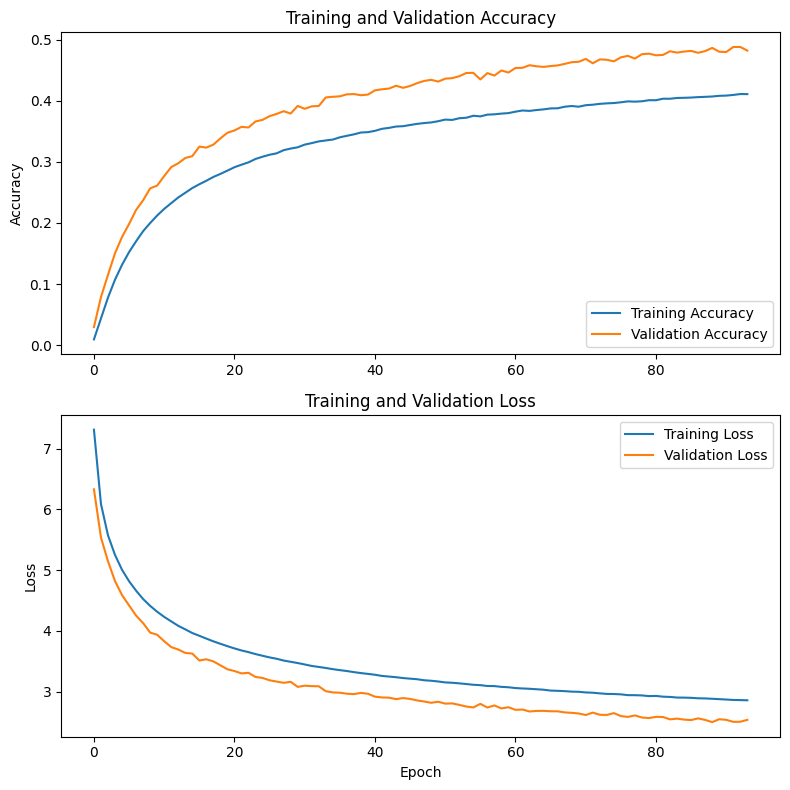

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()